### Импорт библиотек

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt

# Часть 1: Бинарная классификация. Случай линейно разделимых классов

В этой работе решалась задача определения шанса абитуриента поступить в институт по известным результатам его двух экзаменов.

### Загрузка данных


In [11]:
data = pd.read_csv('data/ex2data1.txt', names=['Exam 1 Score', 'Exam 2 Score', 'target'])
data.head()

,Exam 1 Score,Exam 2 Score,target
0,34.623660,78.024693,0
1,30.286711,43.894998,0
2,35.847409,72.902198,0
3,60.182599,86.308552,1
4,79.032736,75.344376,1


### Визуализация данных

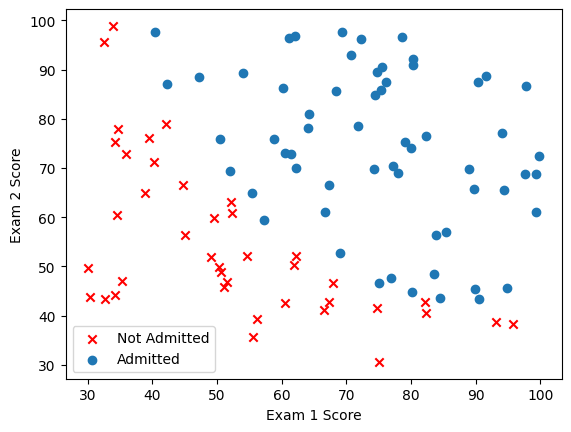

In [12]:
plt.scatter(data[data['target'] == 0]['Exam 1 Score'], data[data['target'] == 0]['Exam 2 Score'], color='red', marker='x', label='Not Admitted')
plt.scatter(data[data['target'] == 1]['Exam 1 Score'], data[data['target'] == 1]['Exam 2 Score'], marker='o', label='Admitted')
plt.legend()
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.show()

### Подготовка данных

In [13]:
X = np.column_stack([np.ones(len(data)), data.iloc[:, :-1]])
y = data.iloc[:, -1].values
theta = np.zeros(X.shape[1])

print(f'X.shape: {X.shape}, y.shape: {y.shape}, theta.shape: {theta.shape}')

X.shape: (100, 3), y.shape: (100,), theta.shape: (3,)


### Определение сигмоиды

In [14]:
def sigmoid(z: float) -> float:
    return 1 / (1 + np.exp(-z))

### Функция стоимости

In [15]:
def costFunc(theta: np.ndarray, X: np.ndarray, y: np.ndarray) -> float:
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    h = sigmoid(X @ theta)
    return (-1 / len(y) * (y.T @ np.log(h) + (1 - y).T @ np.log(1 - h))).item()

print(f'Cost at initial theta: {costFunc(theta, X, y)}')

Cost at initial theta: 0.6931471805599453


### Градиент функции стоимости

In [16]:
def gradientFunc(theta: np.ndarray, X: np.ndarray, y: np.ndarray) -> np.ndarray:
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    h = sigmoid(X @ theta)
    return (1 / len(y) * X.T @ (h - y)).flatten()

print(f'Gradient at initial theta: {gradientFunc(theta, X, y)}')

Gradient at initial theta: [ -0.1        -12.00921659 -11.26284221]


### Оптимизация theta

С помощью функции fmin_tnc из пакета scipy.optimize производится оптимизация параметров θ логистической регрессии. В неё передаются: функция потерь costFunction, начальные значения параметров theta, функция градиента gradientFunc и данные (x, y). Результатом является вектор оптимальных параметров theta_optimized, минимизирующих функцию потерь на обучающих данных.

In [17]:
result = opt.fmin_tnc(
    func = costFunc,
    x0 = theta, fprime = gradientFunc,
    args = (X, y))
theta_optimized = result[0]
print(f'Optimized theta: {theta_optimized}')

Optimized theta: [-25.16131863   0.20623159   0.20147149]


  NIT   NF   F                       GTG
    0    1  6.931471805599453E-01   2.71082898E+02
    1    3  6.318123602631552E-01   7.89087138E-01
    2    5  5.892425287224122E-01   7.39225941E+01
    3    7  4.227824376141017E-01   1.85266372E+01
    4    9  4.072926830765175E-01   1.68671186E+01
    5   11  3.818854956567495E-01   1.07734971E+01
    6   13  3.786234756676171E-01   2.31585015E+01
tnc: stepmx = 1000
    7   16  2.389267275374811E-01   3.00820494E+00
    8   18  2.047203829271571E-01   1.52224031E-01
    9   20  2.046713859363658E-01   6.62489854E-02
   10   22  2.035303176614651E-01   9.30772192E-04
tnc: fscale = 32.7777
   11   24  2.035293535585508E-01   8.07486995E-06
   12   26  2.035251133009459E-01   1.80177414E-04
   13   28  2.034984109185634E-01   5.02814768E-04
   14   30  2.034978383140604E-01   9.92459010E-06
   15   32  2.034977907767076E-01   3.77680317E-06
   16   34  2.034977389327010E-01   1.94873221E-05
   17   36  2.034977015894746E-01   2.29120580E-13


### Построение границы решения

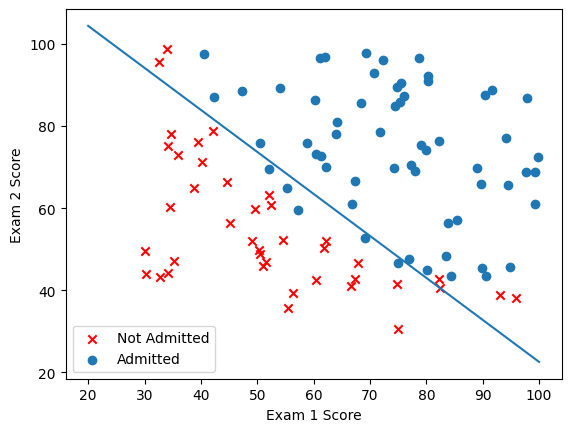

In [18]:
plt.scatter(data[data['target'] == 0]['Exam 1 Score'], data[data['target'] == 0]['Exam 2 Score'], color='red', marker='x', label='Not Admitted')
plt.scatter(data[data['target'] == 1]['Exam 1 Score'], data[data['target'] == 1]['Exam 2 Score'], marker='o', label='Admitted')
plt.legend()
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')

x1_vals = np.linspace(20, 100, 100)
x2_vals = -(theta_optimized[0] + theta_optimized[1] * x1_vals) / theta_optimized[2]
plt.plot(x1_vals, x2_vals, label='Decision Boundary')

plt.show()

### Предсказание

In [19]:
probability = sigmoid(np.dot(np.array([1, 45, 85]), theta_optimized))
print(f'Admitted probability for (45, 85) = {probability}')

Admitted probability for (45, 85) = 0.7762906239849174


### Точность

In [20]:
def predict(x, theta):
    probability = np.array(sigmoid(np.dot(x, theta)))
    predicted = (probability >= 0.5)
    return predicted

predicted = predict(X, theta_optimized)
correct = np.sum(predicted.astype(int) == y.reshape(100))
total = len(predicted)
print(f'Accuracy: {100 * correct / total}%')

Accuracy: 89.0%
